<a href="https://colab.research.google.com/github/aruna-31/Deep-Learning-practice-and-basic-projects/blob/main/Face_recognition_using_VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.utils import load_img

In [ ]:
lt = [cv2.ROTATE_180,cv2.ROTATE_90_COUNTERCLOCKWISE,cv2.ROTATE_90_CLOCKWISE]
def brightness(img):
    value = random.uniform(0.5, 2)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv = np.array(hsv, dtype = np.float64)
    hsv[:,:,1] = hsv[:,:,1]*value
    hsv[:,:,1][hsv[:,:,1]>255]  = 255
    hsv[:,:,2] = hsv[:,:,2]*value
    hsv[:,:,2][hsv[:,:,2]>255]  = 255
    hsv = np.array(hsv, dtype = np.uint8)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return img

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#assigning directory
import pathlib
import glob
directory=pathlib.Path("/content/drive/My Drive/Indian_actors_faces")
import pathlib
import glob
directory=pathlib.Path("/content/drive/My Drive/Indian_actors_faces")

In [ ]:
resultant="/content/augmentedimages"

In [ ]:
import os
import cv2
import random
import numpy as np
from keras.applications.vgg16 import preprocess_input # Import here as it's used with images

os.makedirs(resultant, exist_ok=True)
root_items = os.listdir(directory)

classes = []
images_list = []
labels_list = []
class_idx = 0

for item_name in root_items:
    item_path = os.path.join(directory, item_name)

    if os.path.isdir(item_path):
        classes.append(item_name)
        print(f"Processing class: {item_name}")

        for image_file_name in os.listdir(item_path):
            image_path = os.path.join(item_path, image_file_name)

            if os.path.isdir(image_path) or not image_file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                continue

            img_original = cv2.imread(image_path)
            if img_original is None:
                print(f"Skipping unreadable file: {image_path}")
                continue

            img = cv2.resize(img_original, (224, 224))

            # Append original image
            images_list.append(img)
            labels_list.append(class_idx)

            # Data augmentation
            a = random.randint(5, 10)
            while a > 0:
                aug_img = cv2.rotate(img, lt[random.randint(0, 2)])
                images_list.append(aug_img)
                labels_list.append(class_idx)

                if a % 2 == 0:
                    bright_img = brightness(aug_img)
                    images_list.append(bright_img)
                    labels_list.append(class_idx)
                a -= 1
        class_idx += 1
    else:
        print(f"Skipping non-directory item in root: {item_name}")

if len(images_list) > 0:
    images_raw = np.array(images_list) # Keep raw images in uint8
    images = preprocess_input(images_raw) # Preprocess and convert to float32
    labels = np.array(labels_list, dtype=np.int32)

    # Check shape after conversion
    if images.shape[0] > 0 and images.shape[1:] != (224, 224, 3):
        print(f"Warning: Images array has unexpected shape after preprocessing: {images.shape}")
else:
    images = np.array([], dtype=np.float32)
    labels = np.array([], dtype=np.int32)

print(f"Total images loaded: {len(images_list)}")
print(f"Shape of images array: {images.shape if images.size > 0 else 'empty'}")
print(f"Dtype of images array: {images.dtype}")


Processing class: vinod_khanna
Skipping unreadable file: /content/drive/My Drive/Indian_actors_faces/vinod_khanna/104b15e619.jpg
Skipping unreadable file: /content/drive/My Drive/Indian_actors_faces/vinod_khanna/29b3e3d30e.jpg
Skipping unreadable file: /content/drive/My Drive/Indian_actors_faces/vinod_khanna/3146f0e897.jpg
Skipping unreadable file: /content/drive/My Drive/Indian_actors_faces/vinod_khanna/6716771e00.jpg
Skipping non-directory item in root: vidya_balan
Skipping non-directory item in root: sridevi
Skipping non-directory item in root: tabu
Skipping non-directory item in root: waheeda_rehman
Skipping non-directory item in root: zarina_wahab
Skipping non-directory item in root: varun_dhawan
Skipping non-directory item in root: zeenat_aman
Skipping non-directory item in root: sunny_deol
Skipping non-directory item in root: soumitra_chatterjee
Skipping non-directory item in root: tinnu_anand
Skipping non-directory item in root: sunil_shetty
Skipping non-directory item in root:

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32 # You can adjust this value based on your available memory

# Create a tf.data.Dataset from your images and labels
dataset = tf.data.Dataset.from_tensor_slices((images, labels))
dataset = dataset.shuffle(buffer_size=len(images)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Created tf.data.Dataset with batch size: {BATCH_SIZE}")

Created tf.data.Dataset with batch size: 32


In [ ]:
if 'images' in globals():
    print(images.shape)
else:
    print("Error: The 'images' variable is not defined. Please ensure the cell where 'images' is created (cell ktmV1KWKAKYI) has been executed in the current session.")

from keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import *
from keras.applications.vgg16 import VGG16, preprocess_input

(462, 224, 224, 3)


In [ ]:
model = VGG16(weights="imagenet")
for i in model.layers:
    i.trainable =  False

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
len(model.layers)

23

In [ ]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 138,357,544 (527.79 MB)

In [ ]:
transferVGG = Sequential()

# adding layers from pre-trained model
for i in range(18):
    transferVGG.add(model.layers[i])

In [ ]:
# adding custum layers
transferVGG.add(Flatten())
transferVGG.add(Dense(512,activation="relu"))
transferVGG.add(Dense(128,activation="relu"))
transferVGG.add(Dense(13,activation="softmax"))

In [ ]:
transferVGG.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,162,765 (252.39 MB)

 Trainable params: 51,448,077 (196.26 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:

import tensorflow as tf
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        print("call")
        if(logs.get('accuracy') > .99):
            print("\nReached %2.2f%% accuracy, so stopping training!!" %(99))
            self.model.stop_training = True
callbacks = myCallback()


In [ ]:

# model1.summary()
transferVGG.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
transferVGG.fit(images,labels,epochs=100,callbacks=[callbacks])


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.7786 - loss: 3.4746call
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 697ms/step - accuracy: 0.9307 - loss: 1.0871
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 0.0000e+00call

Reached 99.00% accuracy, so stopping training!!
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 1.0000 - loss: 0.0000e+00


In [ ]:
# Compile the model if not already compiled (or re-compile if you change layers/optimizer)
transferVGG.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

# Fit the model using the tf.data.Dataset
transferVGG.fit(dataset, epochs=100, callbacks=[callbacks])

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 0.0000e+00call

Reached 99.00% accuracy, so stopping training!!
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 1.0000 - loss: 0.0000e+00


In [ ]:
transferVGG.evaluate(images,labels)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 229ms/step - accuracy: 1.0000 - loss: 0.0000e+00


[0.0, 1.0]

In [ ]:
def predict(i,transferVGG,labels):
    path1 = f"{directory}/{i}"
    img = cv2.imread(path1)
    img = cv2.resize(img,(224,224))
    a = np.argmax(transferVGG.predict(np.array([img])))
    img = cv2.putText(img, labels[a], (25,25), cv2.FONT_HERSHEY_SIMPLEX,1, (225,225,0), 3, cv2.LINE_AA)
    plt.imshow(img)

['vinod_khanna', 'vidya_balan', 'sridevi', 'tabu', 'waheeda_rehman', 'zarina_wahab', 'varun_dhawan', 'zeenat_aman', 'sunny_deol', 'soumitra_chatterjee', 'tinnu_anand', 'sunil_shetty', 'utpal_dutt', 'shreyas_talpade', 'smita_patil', 'shashi_kapoor', 'shah_rukh_khan', 'sharmila_tagore', 'sanjay_mishra', 'saif_ali_khan', 'sharman_joshi', 'shabana_azmi', 'salman_khan', 'sanjay_dutt', 'sachin_khedekar', 'saeed_jaffrey', 'richa_chadha', 'riteish_deshmukh', 'rishi_kapoor', 'rekha', 'ratna_pathak_shah', 'ranvir_shorey', 'randeep_hooda', 'ramya_krishnan', 'ranveer_singh', 'rani_mukerji', 'rajinikanth', 'ranbir_kapoor', 'rajesh_khanna', 'rajpal_yadav', 'rajkummar_rao', 'raj_babbar', 'rajit_kapoor', 'rakhee_gulzar', 'raj_kapoor', 'rajat_kapoor', 'radhika_apte', 'rahul_bose', 'priyanka_chopra', 'prem_chopra', 'raaj_kumar', 'pran', 'pankaj_kapur', 'pawan_malhotra', 'prakash_raj', 'paresh_rawal', 'pankaj_tripathi', 'prabhu_deva', 'prabhas', 'pooja_bhatt', 'nawazuddin_siddiqui', 'neeraj_kabi', 'om_pu

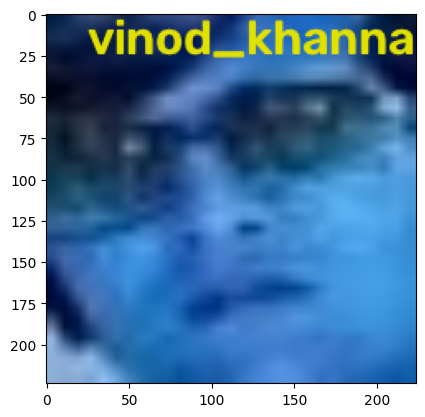

In [ ]:
# The previous call `predict(".jpg",transferVGG,classes)` resulted in an error because ".jpg" is not a valid image file.
# You need to provide a relative path to an actual image file within your dataset.

# Example of how to find a valid image path:
import os
print(os.listdir(directory)) # This will show class folders like 'vinod_khanna'
if 'vinod_khanna' in os.listdir(directory):
      class_path = os.path.join(directory, 'vinod_khanna')
      print(os.listdir(class_path)) # This will show actual image filenames within that class

predict("vinod_khanna/0b035338f4.jpg", transferVGG, classes)

### More Prediction Examples
Let's test the model with a few more images from different classes.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


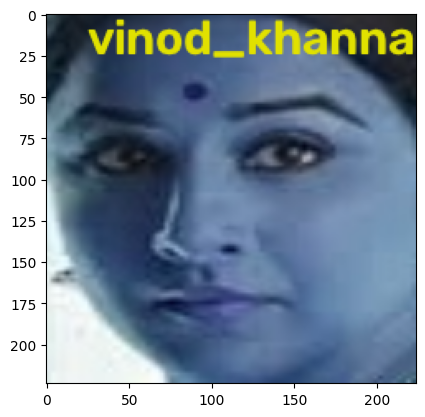

In [ ]:
# Example for 'vidya_balan'
if 'vidya_balan' in os.listdir(directory):
    class_path_vidya = os.path.join(directory, 'vidya_balan')
    vidya_images = os.listdir(class_path_vidya)
    if vidya_images:
        # Pick the first image found for 'vidya_balan'
        predict(f"vidya_balan/{vidya_images[0]}", transferVGG, classes)
    else:
        print("No images found for 'vidya_balan'.")
else:
    print("'vidya_balan' class folder not found.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


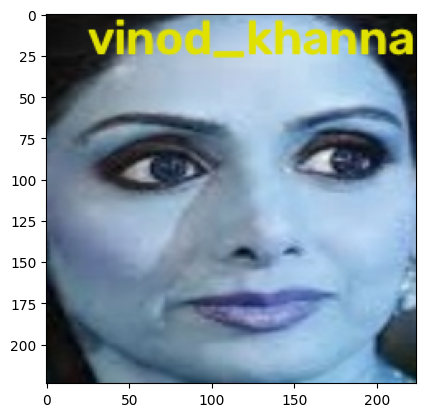

In [ ]:
# Example for 'sridevi'
if 'sridevi' in os.listdir(directory):
    class_path_sridevi = os.path.join(directory, 'sridevi')
    sridevi_images = os.listdir(class_path_sridevi)
    if sridevi_images:
        # Pick the first image found for 'sridevi'
        predict(f"sridevi/{sridevi_images[0]}", transferVGG, classes)
    else:
        print("No images found for 'sridevi'.")
else:
    print("'sridevi' class folder not found.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


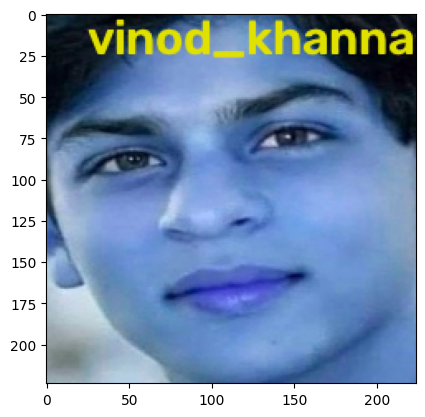

In [ ]:
# Example for 'shah_rukh_khan'
if 'shah_rukh_khan' in os.listdir(directory):
    class_path_srk = os.path.join(directory, 'shah_rukh_khan')
    srk_images = os.listdir(class_path_srk)
    if srk_images:
        # Pick the first image found for 'shah_rukh_khan'
        predict(f"shah_rukh_khan/{srk_images[0]}", transferVGG, classes)
    else:
        print("No images found for 'shah_rukh_khan'.")
else:
    print("'shah_rukh_khan' class folder not found.")